# Notebook 1: Introduction to Embeddings and Similarity



**What you will learn**
1. What an *embedding* is: a list of numbers that represents the meaning of a text
2. How to measure how similar two texts are (*cosine similarity*)
3. How to search a small collection by meaning rather than by keywords
4. How embeddings work across languages (English and Arabic)

**How to run this notebook:** Click *Runtime > Run all*, or run each cell in order with the play button (or `Shift+Enter`). No API key is needed. Everything runs free in Google Colab.

## 0. Setup

The next cell installs the libraries we need. It may take a minute the first time.

In [1]:
!pip install -q sentence-transformers scikit-learn matplotlib pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from sklearn.decomposition import PCA

## 1. What is an embedding?

Computers cannot read words the way we do. An **embedding model** converts a piece of text into a long list of numbers (a *vector*). The key idea is that **texts with similar meaning get similar numbers**.

We will use a free, open model called `paraphrase-multilingual-MiniLM-L12-v2`. It understands more than 50 languages, including Arabic. The first run downloads the model (about 450 MB).

In [3]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("Model loaded.")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.


In [4]:
sentence = "The library of Alexandria was a great centre of learning."
vector = model.encode(sentence)

print("Type of object :", type(vector))
print("Vector length  :", vector.shape[0], "numbers")
print("First 8 numbers:", np.round(vector[:8], 3))

Type of object : <class 'numpy.ndarray'>
Vector length  : 384 numbers
First 8 numbers: [ 0.523  0.143 -0.818  0.034 -0.362 -0.016 -0.023 -0.263]


Our sentence is now represented by 384 numbers. Individual numbers are not meaningful to humans. What matters is how vectors **compare to each other**.

## 2. Measuring similarity with cosine similarity

Imagine each vector as an arrow in space. **Cosine similarity** measures the angle between two arrows:

- close to **1**: arrows point the same way (very similar meaning)
- close to **0**: unrelated
- below 0: roughly opposite (rare in practice for ordinary text)

The formula is simple enough to write ourselves.

In [5]:
def cosine_similarity(a, b):
    """Dot product of the two vectors, divided by the product of their lengths."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

pairs = [
    ("The scholar studied ancient manuscripts.", "The researcher read old handwritten texts."),
    ("The scholar studied ancient manuscripts.", "The football match ended in a draw."),
    ("The king ruled the empire for forty years.", "The monarch governed the realm for four decades."),
]

for s1, s2 in pairs:
    v1, v2 = model.encode(s1), model.encode(s2)
    print(f"{cosine_similarity(v1, v2):.2f}  |  {s1}  <->  {s2}")

0.75  |  The scholar studied ancient manuscripts.  <->  The researcher read old handwritten texts.
-0.03  |  The scholar studied ancient manuscripts.  <->  The football match ended in a draw.
0.65  |  The king ruled the empire for forty years.  <->  The monarch governed the realm for four decades.


Notice that the first and third pairs use **different words** but get a high score because the meaning is close. The second pair is unrelated and scores low. This is what makes embeddings more powerful than keyword matching.

## 3. Comparing many texts at once

With a list of sentences we can compute a full similarity matrix and display it as a heatmap.

S1 - The poet wrote verses about love and loss.
S2 - The author composed a poem about heartbreak.
S3 - The historian analysed medieval trade routes.
S4 - Merchants travelled along the Silk Road.
S5 - The recipe needs two eggs and a cup of flour.


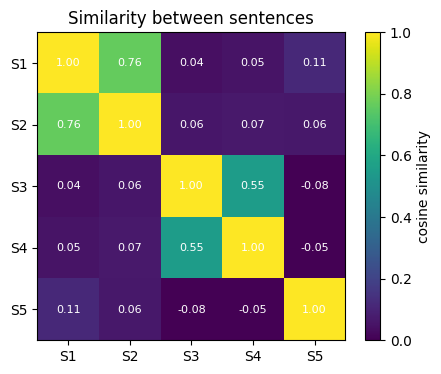

In [6]:
sentences = [
    "The poet wrote verses about love and loss.",
    "The author composed a poem about heartbreak.",
    "The historian analysed medieval trade routes.",
    "Merchants travelled along the Silk Road.",
    "The recipe needs two eggs and a cup of flour.",
]

embeddings = model.encode(sentences)
sim_matrix = sk_cosine(embeddings)

labels = [f"S{i+1}" for i in range(len(sentences))]
for label, s in zip(labels, sentences):
    print(label, "-", s)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels)
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)
plt.colorbar(im, label="cosine similarity")
plt.title("Similarity between sentences")
plt.show()

**What to look for:** S1 and S2 (poetry) are close; S3 and S4 (history and trade) are close; S5 (cooking) is far from everything else.

## 4. Embeddings across languages (English and Arabic)

A *multilingual* model places sentences with the same meaning near each other **even in different languages**. Let us test this with Arabic.

In [7]:
english = [
    "The library is a place for books.",
    "I like to eat apples.",
    "Knowledge is light and ignorance is darkness.",
]
arabic = [
    "المكتبة مكان للكتب.",
    "أحب أكل التفاح.",
    "العلم نور والجهل ظلام.",
]

en_vecs = model.encode(english)
ar_vecs = model.encode(arabic)
cross = sk_cosine(en_vecs, ar_vecs)

for i, en in enumerate(english):
    best = int(np.argmax(cross[i]))
    print(f"English : {en}")
    print(f"Best Arabic match: {arabic[best]}  (score {cross[i][best]:.2f})")
    print()

English : The library is a place for books.
Best Arabic match: المكتبة مكان للكتب.  (score 0.98)

English : I like to eat apples.
Best Arabic match: أحب أكل التفاح.  (score 0.96)

English : Knowledge is light and ignorance is darkness.
Best Arabic match: العلم نور والجهل ظلام.  (score 0.85)



In [8]:
# The full table of scores (rows = English sentences, columns = Arabic sentences)
pd.DataFrame(
    np.round(cross, 2),
    index=[f"EN{i+1}" for i in range(len(english))],
    columns=[f"AR{i+1}" for i in range(len(arabic))],
)

,AR1,AR2,AR3
EN1,0.98,0.05,0.25
EN2,0.04,0.96,0.06
EN3,0.27,0.08,0.85


Each English sentence should match its Arabic translation best (the diagonal of the table has the highest values). The model never saw these exact pairs. It learned a shared "meaning space" for many languages.

> **Note for researchers:** Quality varies by language, dialect and period. Classical Arabic, dialectal Arabic and Modern Standard Arabic may behave differently. Always test on a sample of *your own* material.

## 5. Semantic search: find documents by meaning

A common use of embeddings is **search**. We embed a small collection of documents once, embed the query, and rank documents by similarity.

In [9]:
documents = [
    "The House of Wisdom in Baghdad was a major centre for translating Greek texts into Arabic.",
    "Gutenberg's printing press made it possible to produce books quickly and cheaply in Europe.",
    "Ibn Battuta travelled across Africa, Asia and Europe in the fourteenth century.",
    "The Rosetta Stone helped scholars decipher Egyptian hieroglyphs.",
    "Medieval monks copied manuscripts by hand in scriptoria.",
    "Digital archives allow researchers to search millions of scanned newspapers.",
    "The Silk Road connected China with the Mediterranean world through trade.",
]
doc_vecs = model.encode(documents)

def search(query, top_k=3):
    q_vec = model.encode(query)
    scores = sk_cosine([q_vec], doc_vecs)[0]
    ranking = np.argsort(scores)[::-1][:top_k]
    print(f"Query: {query}\n")
    for rank, idx in enumerate(ranking, start=1):
        print(f"{rank}. ({scores[idx]:.2f}) {documents[idx]}")
    print()

search("Who made copies of books before printing existed?")
search("famous medieval travellers")
search("كيف ترجم العلماء الكتب اليونانية؟")   # Arabic query on English documents

Query: Who made copies of books before printing existed?

1. (0.47) Medieval monks copied manuscripts by hand in scriptoria.
2. (0.44) Gutenberg's printing press made it possible to produce books quickly and cheaply in Europe.
3. (0.30) The Rosetta Stone helped scholars decipher Egyptian hieroglyphs.

Query: famous medieval travellers

1. (0.41) Ibn Battuta travelled across Africa, Asia and Europe in the fourteenth century.
2. (0.39) Medieval monks copied manuscripts by hand in scriptoria.
3. (0.35) The Rosetta Stone helped scholars decipher Egyptian hieroglyphs.

Query: كيف ترجم العلماء الكتب اليونانية؟

1. (0.48) The House of Wisdom in Baghdad was a major centre for translating Greek texts into Arabic.
2. (0.45) Medieval monks copied manuscripts by hand in scriptoria.
3. (0.36) The Rosetta Stone helped scholars decipher Egyptian hieroglyphs.



Even though the queries share few words with the documents, the right results appear near the top. The last query is in **Arabic** and still finds English documents.

**Try it yourself:** change the query, or replace `documents` with sentences from your own research corpus.

## 6. Visualising the "meaning space"

Vectors have 384 dimensions, which we cannot draw. A technique called **PCA** squeezes them down to 2 dimensions while keeping as much structure as possible. Similar texts end up near each other.

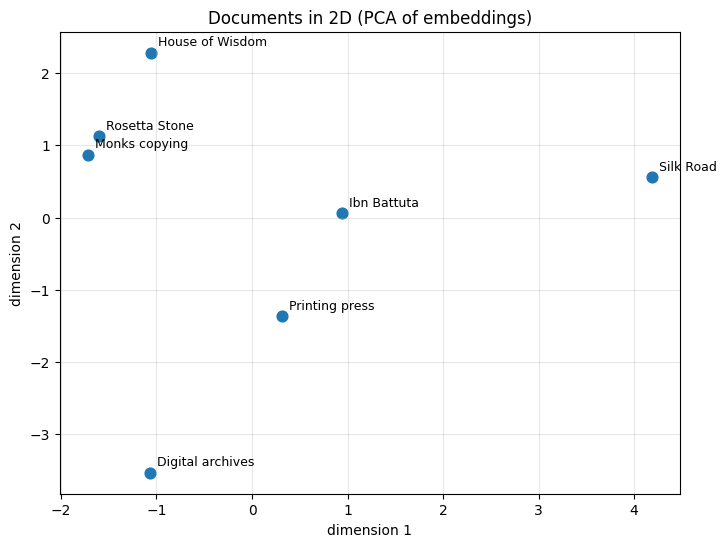

In [10]:
points = PCA(n_components=2).fit_transform(doc_vecs)

plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], s=60)
short_labels = ["House of Wisdom", "Printing press", "Ibn Battuta", "Rosetta Stone",
                "Monks copying", "Digital archives", "Silk Road"]
for (x, y), label in zip(points, short_labels):
    plt.annotate(label, (x, y), xytext=(5, 5), textcoords="offset points", fontsize=9)
plt.title("Documents in 2D (PCA of embeddings)")
plt.xlabel("dimension 1")
plt.ylabel("dimension 2")
plt.grid(alpha=0.3)
plt.show()

Do the clusters make sense? Texts about trade and travel, and texts about books and writing, tend to sit together. Remember that this 2D picture is a lossy summary, so treat it as an aid to intuition.

## Key takeaways

- An **embedding** turns text into numbers that capture meaning.
- **Cosine similarity** compares two embeddings (1 = very similar, 0 = unrelated).
- Embeddings enable **search by meaning**, **clustering** and **cross-lingual comparison**.
- Results depend on the model. Always inspect them on your own data.

## Exercises

1. Add three sentences from your own research area to `documents` and run new searches.
2. Find two sentences that **you** think are similar but the model scores low. Why might that be?
3. Try another language you work with. Does the model still match translations?

**Next:** Notebook 2 shows how to store embeddings in a *vector database* so search stays fast on thousands or millions of documents.